# Challenge 2

This challenge is about OSMnx. You will explore and analyze a city's street network using the OSMnx Python library.

1. Use OSMnx to download the street network of a city of your choice. You can specify the city name, BBox or a Dict.
2. Calculate basic statistics for the street network, such as the number of nodes, edges, average node degree, etc.
3. Use OSMnx to plot the street network. Customize the plot to make it visually appealing, including node size, edge color. See the potential options here: https://osmnx.readthedocs.io/en/stable/user-reference.html#module-osmnx.plot
4. Utilize the routing capabilities of OSMnx to find the shortest path between two points in the street network. Plot the route on top of the street network.
5. Calculate the centrality measures (e.g., degree centrality and betweenness_centrality) for nodes in the street network.
6. Create the figure-groud from the selected city
7. Create interactive maps to plot nodes, edges, nodes+edges and one of the centrality measures.
8. Export the street network to a GeoPackage (.gpkg) file. Ensure that the exported file contains both node and edge attributes. Demonstrate that the new GeoPackage can be used and read in Python using any of the libraries we have seen in the class to create a simple and interactive map.
9. Finally, use OSMnx to extract other urban elements (e.g., buildings, parks) and plot them.

In [12]:
import networkx as nx
import osmnx as ox

In [40]:
#downloading our chosen street network of San Diego
# through making a query in the form of a dict
place = {"city": "San Diego", "state": "California", "country": "USA"}
G = ox.graph_from_place(place, network_type="drive", truncate_by_edge=True)

In [41]:
#calculating basic statistics for the street network, such as number of nodes, edges, average node degree etc.

In [33]:
#calculating number of nodes
print("The graph has", len(G.nodes), "nodes")

#calculating number of edges
print("The graph has", len(G.edges), "edges")

The graph has 27324 nodes
The graph has 66938 edges


In [34]:
#exploring the data type of nodes
print("The nodes are", print(type(G.nodes)))

<class 'networkx.classes.reportviews.NodeView'>
The nodes are None


In [35]:
#exploring the data type of edges
print("The edges are", print(type(list(G.edges(data=True))[0])))

<class 'tuple'>
The edges are None


In [38]:
#exploring elements of the first and last nodes
print(list(G.nodes(data=True))[0])
print(list(G.nodes(data=True))[-1])

(48857412, {'y': 32.823986, 'x': -117.100731, 'street_count': 3})
(12658070290, {'y': 32.8923715, 'x': -117.1639653, 'street_count': 3})


In [37]:
#exploring elements of the first and last edges
print(list(G.edges(data=True))[0])
print(list(G.edges(data=True))[-1])

(48857412, 1429663812, {'osmid': 5938355, 'highway': 'residential', 'name': 'Esplendente Boulevard', 'oneway': False, 'reversed': True, 'length': np.float64(93.31255574856051), 'geometry': <LINESTRING (-117.101 32.824, -117.101 32.824, -117.101 32.823, -117.101 32....>})
(12658070290, 12658070289, {'osmid': 1366759952, 'highway': 'residential', 'oneway': False, 'reversed': True, 'length': np.float64(6.872235776676256)})


In [ ]:
#calculating average node degree 
nx.average_neighbor_degree(G, weight="weight")

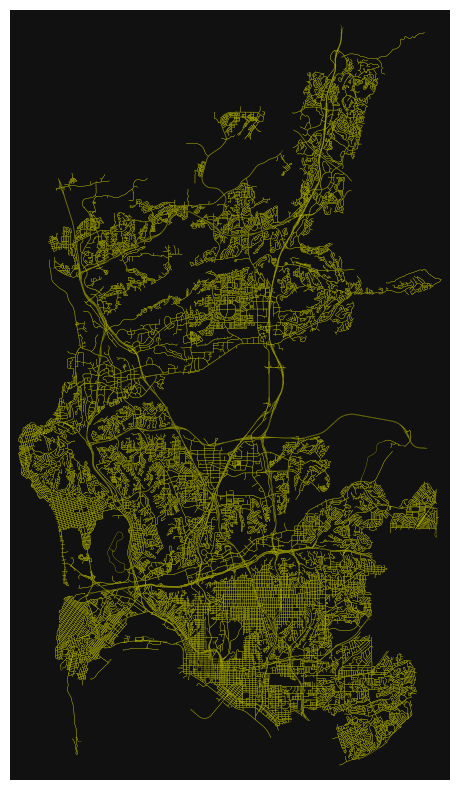

In [39]:
#plotting street network using OSMnx
fig, ax = ox.plot_graph(G, figsize=(10, 10), node_size=0, edge_color="y", edge_linewidth=0.2)

In [ ]:
#customising the node size and edge color

In [ ]:
#first, changing the color and figure size
fig, ax = ox.plot_graph(G, figsize=(6, 4), node_size=0, edge_color="k", edge_linewidth=0.2)

In [ ]:
#second, visualising street centrality using color
edge_centrality = nx.closeness_centrality(nx.line_graph(G))

ev = [edge_centrality[edge + (0,)] for edge in G.edges()]

# color scale converted to list of colors for graph edges
norm = colors.Normalize(vmin=min(ev)*0.8, vmax=max(ev))
cmap = cm.ScalarMappable(norm=norm, cmap=cm.inferno)
ec = [cmap.to_rgba(cl) for cl in ev]

# color the edges in the original graph with closeness centralities in the line graph
fig, ax = ox.plot_graph(G, bgcolor='k', axis_off=True, node_size=0,
                        edge_color=ec, edge_linewidth=1.5, edge_alpha=1)

Reference: gboeing (2017). osmnx-examples/notebooks/00-osmnx-features-demo.ipynb at v0.13.0 · gboeing/osmnx-examples. [online] GitHub. Available at: https://github.com/gboeing/osmnx-examples/blob/v0.13.0/notebooks/00-osmnx-features-demo.ipynb [Accessed 16 Mar. 2025].

In [ ]:
#utilise the routing capabilities of OSMnx to find the shortest path between two points 

#establishing origin
orig = list(G)[0]

#establishing destination
dest = list(G)[-1]

#plot the route
route = nx.shortest_path(G, orig, dest, weight='length')
fig, ax = ox.plot_graph_route(G, route, route_linewidth=2, node_size=0, bgcolor='k')

Reference: Geoff Boeing. (2016). OSMnx: Python for Street Networks. [online] Available at: https://geoffboeing.com/2016/11/osmnx-python-street-networks/.

In [ ]:
#calculating centrality measures
#calculating degree centrality
#calculating betweenness centrality

In [ ]:
#creating figoure-groud from the selected city

In [ ]:
#creating interactive maps to plot nodes, edges, nodes+edges and one of centrality measures

In [ ]:
#exporting street network to a geopackage file

In [ ]:
#reading the geopackage file in python

In [ ]:
#using OSMnx to extract other urban elements e.g. buildings, parks and plotting them